
# 4 &mdash; The rest of the App. B gallery: B.5, B.6, B.7

These three are not just extra targets; each exercises a part of the machinery
that nothing else in the examples touches:

* **B.5** CV graph-state emitter &rarr; quadratic-form pins (`pin_form`): a
  nullifier variance $\mathrm{Var}(p_i - x_j)$ is not a single entry of
  $\sigma_\mathrm{out}$.
* **B.6** backaction-evading readout &rarr; a single pinned cross-term,
  everything else free.
* **B.7** noise diode &rarr; a *declared non-vacuum* input covariance; the
  directionality is visible only because $\sigma_\mathrm{in} \neq \mathbb{1}$.

Each runs the complete Sec. 6 search and then checks, on the cheapest device
found, that the emitted field really has the pinned property.

Script version: `examples/04_gallery_sweep.py`.

In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from autogaussian import (
    CovarianceArchitectureOptimizer,
    plot_list_of_graphs,
    qidx,
    solution_table,
)
from autogaussian.gallery import (
    backaction_evading_readout,
    cv_graph_state,
    noise_diode,
)

SUMMARY = []
KWARGS_OPTIMIZATION = {"num_tests": 15}


def search(problem, num_auxiliary_modes=0, seed=11):
    optimizer = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=seed,
        make_initial_test=False, kwargs_optimization=KWARGS_OPTIMIZATION,
        **problem.optimizer_kwargs())
    irreducibles = optimizer.perform_breadth_first_search(progress=False)
    return optimizer, irreducibles


def show(optimizer, irreducibles, limit=6, parameters=True):
    order = np.argsort([int(np.sum(graph)) for graph in irreducibles])
    print("%i irreducible graphs (%i oracle calls):"
          % (len(irreducibles), sum(optimizer.num_tested_graphs)))
    for rank, idx in enumerate(order):
        if rank == limit:
            print("   ... and %i more" % (len(order) - limit))
            break
        graph = irreducibles[idx]
        print("   complexity %i:  %s"
              % (int(np.sum(graph)), ", ".join(optimizer.space.describe(graph))))
    if parameters:
        # the same list with the converged solution behind every architecture
        print()
        print(solution_table(optimizer, irreducibles, limit=limit))
    return irreducibles[order[0]]


def cheapest_solution(optimizer, graph):
    solution = optimizer.solution_of(graph)
    if solution is None:                       # re-solve if it was not cached
        success, infos = optimizer.test_graph(graph, num_tests=30)
        solution = infos[-1]
    return solution


def draw(optimizer, irreducibles, limit=10):
    fig, axes = plot_list_of_graphs(list(irreducibles)[:limit], optimizer.space)
    plt.show()


## B.5 &mdash; CV graph state

Both nullifiers of the 2-node graph pinned to $\varepsilon = 0.1$.

CovarianceTarget(CV graph state, 2 ports, 2 pins)
  Var(v.R)(Omega=0) = 0.1   v=[ 0.  1. -1.  0.]  (w=1)
  Var(v.R)(Omega=0) = 0.1   v=[-1.  0.  0.  1.]  (w=1)
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


test 66 graphs with 5 degrees of freedom:


test 47 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 21 graphs with 3 degrees of freedom:


test 9 graphs with 2 degrees of freedom:


test 2 graphs with 1 degrees of freedom:
valid: 164    invalid: 77 (certified 1, uncertified 76)    oracle calls: 2536    escalations: 75
optimisation finished, list of irreducible graphs has 3 elements (76 uncertified rejections)
3 irreducible graphs (228 oracle calls):
   complexity 1:  two-mode squeezing 0-1 (real)
   complexity 4:  beam-splitter 0-1 (complex), on-site squeezing 0 (real), on-site squeezing 1 (real)
   complexity 5:  beam-splitter 0-1 (real), on-site squeezing 0 (complex), on-site squeezing 1 (complex)

3 valid graph(s), with the converged parameters:

#0  complexity=1  couplings=1  pumps=1
      two-mode squeezing 0-1 (real)
      loss=2.86e-13   max Re eig(M~)=-0.1827
      cooperativities:
         C^{SQZ}_{0,1}        +0.4026
      phases:
         arg(nu_{0,1})        +3.1416
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000

#1  complexity=4  couplings=3  pumps=3
      beam-splitter 0-1 (complex)
      on-site squee

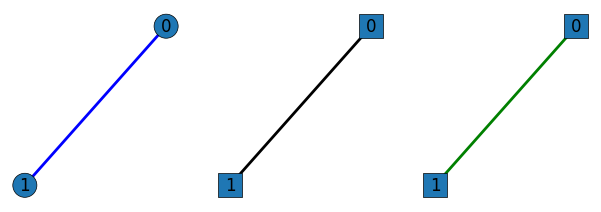

In [3]:
epsilon = 0.1
problem = cv_graph_state(edges=((0, 1),), epsilon=epsilon, num_ports=2)
print(problem.target)

optimizer_gs, irreducibles_gs = search(problem)
best_gs = show(optimizer_gs, irreducibles_gs)
draw(optimizer_gs, irreducibles_gs)

In [4]:
first = np.zeros(4)
first[qidx(0, 1)], first[qidx(1, 0)] = 1.0, -1.0        # p_0 - x_1
second = np.zeros(4)
second[qidx(1, 1)], second[qidx(0, 0)] = 1.0, -1.0      # p_1 - x_0

print("every irreducible device, both nullifiers:")
for graph in irreducibles_gs:
    solution = optimizer_gs.solution_of(graph)
    if solution is None:
        continue
    V = np.real(optimizer_gs.oracle.covariance(solution["x"], 0.0))
    print("   %-62s %.4f / %.4f   margin %.3f"
          % (", ".join(optimizer_gs.space.describe(graph)),
             first @ V @ first, second @ V @ second,
             solution["max_real_eigenvalue"]))
print("   (vacuum would give 2.0 for each; stability margin must be < 0)")

solution = cheapest_solution(optimizer_gs, best_gs)
V = np.real(optimizer_gs.oracle.covariance(solution["x"], 0.0))
achieved = float(first @ V @ first)
SUMMARY.append(("B.5 CV graph state", len(irreducibles_gs),
                "both nullifiers = %.4f" % achieved))

every irreducible device, both nullifiers:


   two-mode squeezing 0-1 (real)                                  0.1000 / 0.1000   margin -0.183
   beam-splitter 0-1 (real), on-site squeezing 0 (complex), on-site squeezing 1 (complex) 0.1000 / 0.1000   margin -0.449
   beam-splitter 0-1 (complex), on-site squeezing 0 (real), on-site squeezing 1 (real) 0.1000 / 0.1000   margin -0.272
   (vacuum would give 2.0 for each; stability margin must be < 0)



> **NOTE:** pinning only *one* nullifier admits 12 irreducible devices, several
> of which are two **decoupled** squeezers &mdash; not a cluster state at all
> (Sec. 11). One nullifier per node, as a CV graph state is actually defined,
> cuts that down and every survivor couples the modes.


## B.6 &mdash; backaction-evading readout

$\sigma_{p_0, x_1} = 0$, everything else free.

start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:
test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


test 67 graphs with 5 degrees of freedom:


test 53 graphs with 4 degrees of freedom:


test 31 graphs with 3 degrees of freedom:


test 13 graphs with 2 degrees of freedom:


test 5 graphs with 1 degrees of freedom:


test 1 graphs with 0 degrees of freedom:
valid: 226    invalid: 44 (certified 0, uncertified 44)    oracle calls: 1554    escalations: 43
optimisation finished, list of irreducible graphs has 3 elements (44 uncertified rejections)
3 irreducible graphs (263 oracle calls):
   complexity 1:  beam-splitter 0-1 (real)
   complexity 2:  two-mode squeezing 0-1 (real), on-site squeezing 1 (real)
   complexity 2:  on-site squeezing 0 (real), two-mode squeezing 0-1 (real)

3 valid graph(s), with the converged parameters:

#0  complexity=1  couplings=1  pumps=0
      beam-splitter 0-1 (real)
      loss=1.68e-12   max Re eig(M~)=-0.5000
      cooperativities:
         C^{BS}_{0,1}         +2.2668
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000
      gauge_phases:
         theta_0              +1.1322
         theta_1              +0.6726

#1  complexity=2  couplings=2  pumps=2
      two-mode squeezing 0-1 (real)
      on-site squeezing 1 (real)
     

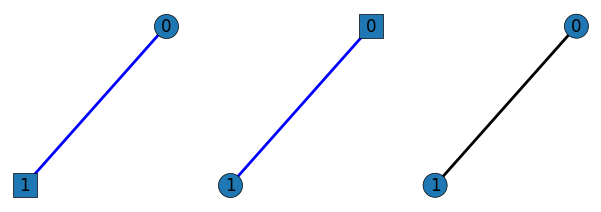

In [5]:
problem = backaction_evading_readout(signal_port=0, probe_port=1)
optimizer_bae, irreducibles_bae = search(problem)
best_bae = show(optimizer_bae, irreducibles_bae)
draw(optimizer_bae, irreducibles_bae)

In [6]:
solution = cheapest_solution(optimizer_bae, best_bae)
V = np.real(optimizer_bae.oracle.covariance(solution["x"], 0.0))
S, _ = optimizer_bae.oracle.scattering(solution["x"], 0.0)
cross = V[qidx(0, 1), qidx(1, 0)]

print("cheapest device: %s" % ", ".join(optimizer_bae.space.describe(best_bae)))
print("sigma_{p_0,x_1} = %.2e   (pinned to 0)" % cross)
print("|S_10|^2 = %.4f      (transmission floor 0.25 keeps the probe coupled)"
      % abs(S[1, 0]) ** 2)
SUMMARY.append(("B.6 backaction evading", len(irreducibles_bae),
                "cross-term %.1e, |S_10|^2 = %.2f" % (cross, abs(S[1, 0]) ** 2)))

cheapest device: beam-splitter 0-1 (real)
sigma_{p_0,x_1} = 1.83e-06   (pinned to 0)
|S_10|^2 = 0.8496      (transmission floor 0.25 keeps the probe coupled)



> **CAVEAT:** with vacuum input a purely passive device emits vacuum, so every
> cross-term is zero and this target is satisfied trivially &mdash; which is why
> the cheapest solution is a bare beam-splitter. App. B.6 as written is
> under-specified (Sec. 11): a real backaction-evading spec also has to pin the
> signal transduction, so that the cross-term vanishing means something.


## B.7 &mdash; noise diode

Thermal input $n = 1.0$ at port 2, port 1 pinned to vacuum.

start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 15 graphs with 8 degrees of freedom:


test 32 graphs with 7 degrees of freedom:


test 48 graphs with 6 degrees of freedom:


...

test 59 graphs with 4 degrees of freedom:


test 40 graphs with 3 degrees of freedom:


test 19 graphs with 2 degrees of freedom:


test 6 graphs with 1 degrees of freedom:


test 1 graphs with 0 degrees of freedom:
valid: 47    invalid: 247 (certified 0, uncertified 247)    oracle calls: 7648    escalations: 251
optimisation finished, list of irreducible graphs has 4 elements (247 uncertified rejections)
4 irreducible graphs (279 oracle calls):
   complexity 4:  beam-splitter 0-1 (real), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)
   complexity 4:  beam-splitter 0-1 (real), two-mode squeezing 0-1 (complex), on-site squeezing 1 (real)
   complexity 4:  beam-splitter 0-1 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (real)
   complexity 5:  detuning Delta_0, beam-splitter 0-1 (complex), on-site squeezing 0 (real), on-site squeezing 1 (real)

4 valid graph(s), with the converged parameters:

#0  complexity=4  couplings=3  pumps=2
      beam-splitter 0-1 (real)
      two-mode squeezing 0-1 (real)
      on-site squeezing 1 (complex)
      loss=9.05e-11   max Re eig(M~)=-0.0011
      cooperativities:
         C^{BS}_{0,1}        

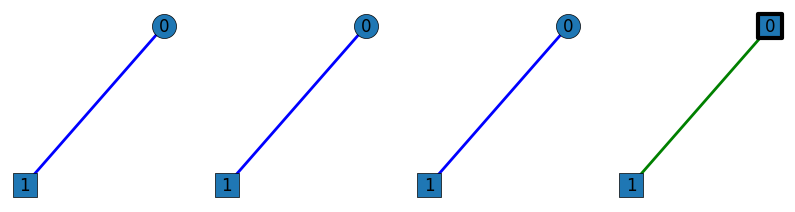

In [7]:
problem = noise_diode(n_thermal=1.0)
optimizer_nd, irreducibles_nd = search(problem)
best_nd = show(optimizer_nd, irreducibles_nd)
draw(optimizer_nd, irreducibles_nd)

In [8]:
solution = cheapest_solution(optimizer_nd, best_nd)
V = np.real(optimizer_nd.oracle.covariance(solution["x"], 0.0))
S, _ = optimizer_nd.oracle.scattering(solution["x"], 0.0)

print("cheapest device: %s" % ", ".join(optimizer_nd.space.describe(best_nd)))
print("port 1 output:  [%.5f, %.5f]   (vacuum floor 1.0, despite the thermal drive)"
      % (V[0, 0], V[1, 1]))
print("port 2 output:  [%.4g, %.4g]   (free -- see caveat)" % (V[2, 2], V[3, 3]))
print("|S_10|^2 = %.4f   |S_01|^2 = %.4f" % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: max Re eig(M~) = %.4f" % solution["max_real_eigenvalue"])
SUMMARY.append(("B.7 noise diode", len(irreducibles_nd),
                "port 1 = %.4f (vacuum), |S_10|^2 = %.2f"
                % (V[0, 0], abs(S[1, 0]) ** 2)))

cheapest device: beam-splitter 0-1 (real), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)
port 1 output:  [1.00001, 1.00001]   (vacuum floor 1.0, despite the thermal drive)
port 2 output:  [2.671e+06, 0.06323]   (free -- see caveat)
|S_10|^2 = 1.3370   |S_01|^2 = 0.0000
stability margin: max Re eig(M~) = -0.0011



The point of this target: with $\sigma_\mathrm{in} =$ vacuum, "port 1 stays at
the vacuum floor" is free. It only bites because port 2 is thermally driven, so
the device has to route that noise away from port 1 (Sec. 1.2).

> **CAVEAT:** port 2's own output is unpinned, and the search drove it to a huge
> value right against the stability boundary &mdash; free entries are free in
> both directions (Sec. 11). Pin them if the emitted state matters.


## Summary

In [9]:
print("%-26s %-14s %s" % ("target", "irreducibles", "verified property"))
print("-" * 74)
for name, count, result in SUMMARY:
    print("%-26s %-14i %s" % (name, count, result))
print("=" * 74)

target                     irreducibles   verified property
--------------------------------------------------------------------------
B.5 CV graph state         3              both nullifiers = 0.1000
B.6 backaction evading     3              cross-term 1.8e-06, |S_10|^2 = 0.85
B.7 noise diode            4              port 1 = 1.0000 (vacuum), |S_10|^2 = 1.34
